# Monotone Piecewise Cubic Interpolation

Xuefeng Xu  
2025-03-13

Piecewise Cubic Hermite Interpolating Polynomial (PCHIP) is a cubic
spline-based interpolation method designed to preserve monotonicity. See
[MATLAB](https://mathworks.com/help/matlab/ref/pchip.html) or
[SciPy](https://docs.scipy.org/doc/scipy/reference/generated/scipy.interpolate.PchipInterpolator.html)
for the implementation details.

## 1 PCHIP Example

Given $n$ data points $(x_1,y_1),\dots,(x_n,y_n)$ with $x_1<\cdots<x_n$,
where $y$ is monotonic (either $y_i\le y_{i+1}$ or $y_{i+1}\ge y_i$).
The easiest interpolation method which preserves monotonicity is linear
interpolation. However, it is not smooth. Polynomial interpolation is
smooth but may introduce overshoots, violating monotonicity.

In [1]:
def plot_interp(interp_func, x, y):
    grid_x = np.linspace(min(x), max(x), 100)
    grid_y = interp_func(grid_x)

    fig, ax = plt.subplots(figsize=(3, 3))
    ax.plot(grid_x, grid_y)
    ax.scatter(x, y, color='C1', zorder=2)

    ax.set_xlabel(r"$x$")
    ax.set_ylabel(r"$y$")

``` python
import numpy as np
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt

x = [-3, -2, -1, 0, 1, 2, 3]
y = [-2, -2, -2, 0, 2, 2, 2]

linear_interp = interp1d(x, y, kind="linear")
plot_interp(linear_interp, x, y)
cubic_interp = interp1d(x, y, kind="cubic")
plot_interp(cubic_interp, x, y)
```

<table>
<colgroup>
<col style="width: 50%" />
<col style="width: 50%" />
</colgroup>
<tbody>
<tr>
<td style="text-align: left;"><div id="cell-fig-linear" class="cell"
data-execution_count="2" width="50.0%" data-layout-align="left">
<div class="cell-output cell-output-display">
<figure id="fig-linear">
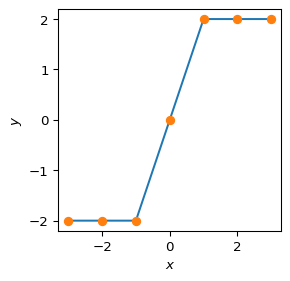
<figcaption>(a) Linear</figcaption>
</figure>
</div>
</div></td>
<td style="text-align: left;"><div id="cell-fig-cubic" class="cell"
data-execution_count="3" width="50.0%" data-layout-align="left">
<div class="cell-output cell-output-display">
<figure id="fig-cubic">
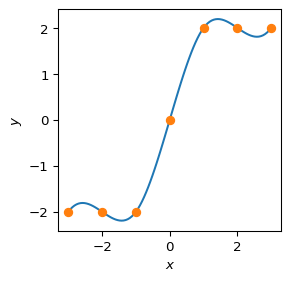
<figcaption>(b) Cubic</figcaption>
</figure>
</div>
</div></td>
</tr>
</tbody>
</table>

Figure 1: Linear Interpolation vs. Cubic Interpolation

One of the most effective interpolation methods that preserves
monotonicity while maintaining smoothness is PCHIP. Some people also
refer to it as shape-preserving cubic interpolation. The following
figures illustrate PCHIP interpolation, where it also appliable to
non-monotonic data points.

``` python
from scipy.interpolate import PchipInterpolator

x = [-3, -2, -1, 0, 1, 2, 3]
y = [-2, -2, -2, 0, 2, 2, 2]

pchip_interp = PchipInterpolator(x, y)
plot_interp(pchip_interp, x, y)
x = [-3, -2, -1, 0, 1, 2, 3]
y = [-2, -1, -1.5, 0, 1, 0.5, 2]

pchip_interp = PchipInterpolator(x, y)
plot_interp(pchip_interp, x, y)
```

<table>
<colgroup>
<col style="width: 50%" />
<col style="width: 50%" />
</colgroup>
<tbody>
<tr>
<td style="text-align: left;"><div id="cell-fig-pchip-monotone"
class="cell" data-execution_count="4" width="50.0%"
data-layout-align="left">
<div class="cell-output cell-output-display">
<figure id="fig-pchip-monotone">
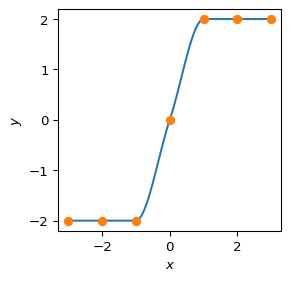
<figcaption>(a) PCHIP on Monotone Data</figcaption>
</figure>
</div>
</div></td>
<td style="text-align: left;"><div id="cell-fig-pchip-nonmonotone"
class="cell" data-execution_count="5" width="50.0%"
data-layout-align="left">
<div class="cell-output cell-output-display">
<figure id="fig-pchip-nonmonotone">
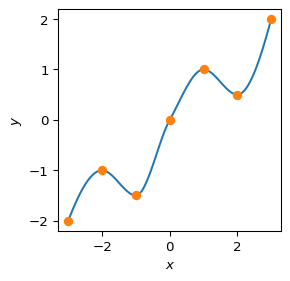
<figcaption>(b) PCHIP on Non-Monotone Data</figcaption>
</figure>
</div>
</div></td>
</tr>
</tbody>
</table>

Figure 2: PCHIP Interpolation on Monotone and Non-Monotone Data

## 2 Interpolation Function

How to ensure cubic interpolation preserves monotonicity? Let’s define
some notations first. For each interval $[x_i,x_{i+1}]$
($i=1,\dots,n-1$), define the step size $h_i$ and slope $s_i$ as:

<span id="eq-h-s">
$$h_i=x_{i+1}-x_i,\ s_i=\frac{y_{i+1}-y_i}{h_i}
 \qquad(1)$$</span>

For $x_i<x<x_{i+1}$, the interpolation function $f(x)$ is a cubic
polynomial:

<span id="eq-cubic-poly">
$$f(x)=c_0+c_1(x-x_i)+c_2(x-x_i)^2+c_3(x-x_i)^3
 \qquad(2)$$</span>

satisfying:

<span id="eq-cubic-poly-cond">
$$\begin{align*}
f(x_i)&=y_i, &f(x_{i+1})&=y_{i+1}\\
f'(x_i)&=d_i, &f'(x_{i+1})&=d_{i+1}
\end{align*}
 \qquad(3)$$</span>

Solving for the coefficients:

<span id="eq-cubic-poly-coef">
$$\begin{align*}
c_0&=y_i, &c_2&=\frac{3s_i-2d_i-d_{i+1}}{h_i}\\
c_1&=d_i, &c_3&=\frac{-2s_i+d_i+d_{i+1}}{h_i^2}\\
\end{align*}
 \qquad(4)$$</span>

Thus, computing derivatives $d_1,\dots,d_n$ determines $c_0,c_1,c_2,c_3$
for each interval.

## 3 Derivative Formula

The derivative $d_i$ is computed using local information from three
neighboring points $\{(x_{i-1},y_{i-1}),(x_i,y_i),(x_{i+1},y_{i+1})\}$.
Replaceing with the slopes $s_{i-1}$ and $s_i$, and step sizes $h_{i-1}$
and $h_i$, the formula is (Fritsch and Butland 1984):

<span id="eq-d">
$$d_i=G(s_{i-1},s_i,h_{i-1},h_i)=
\begin{cases}
\frac{s_{i-1}s_i}{rs_i+(1-r)s_{i-1}} & \mathrm{if~}s_{i-1}s_i>0, \\
0 & \text{otherwise} &
\end{cases}
 \qquad(5)$$</span>

where the ratio $r$ ($1/3<r<2/3$) is given by:

<span id="eq-r">
$$\begin{align*}
r&=\frac{h_{i-1}+2h_i}{3h_{i-1}+3h_i} \\
&=\frac{1}{3}\left(1+\frac{h_i}{h_{i-1}+h_i}\right)
\end{align*}
 \qquad(6)$$</span>

If $s_{i-1}$ and $s_i$ have opposite signs (indicating non-monotonicity)
or one is zero, then $d_i=0$. Otherwise, $d_i$ is a weighted harmonic
mean:

<span id="eq-harmonic-mean">
$$\frac{1}{d_i}=\frac{r}{s_{i-1}}+\frac{1-r}{s_i}
 \qquad(7)$$</span>

For derivatives $d_1$ and $d_n$, they are computed separately (Moler
2004, chap. 3). For $d_1$:

<span id="eq-d1">
$$d_1=
\begin{cases}
0 & \mathrm{if~}\text{sgn}(\hat{d}_1)\neq \text{sgn}(s_1), \\
3s_1 & \mathrm{if~}\text{sgn}(s_1)\neq \text{sgn}(s_2) \land|\hat{d}_1|>3|s_1|,\\
\hat{d}_1 & \text{otherwise} &
\end{cases}
 \qquad(8)$$</span>

where:

<span id="eq-hat-d1">
$$\hat{d}_1=\frac{(2h_1+h_2)s_1 - h_1s_2}{{h_1+h_2}}
 \qquad(9)$$</span>

A quadratic polynomial $\hat{f}(x)=\hat{c}_0+\hat{c}_1x+\hat{c}_2x^2$ is
fit through the first three points, and $\hat{d}_1=\hat{f}'(x_1)$.
Additional rules are then added to preserve monotonicity. Similar
procedures apply for $d_n$.

## 4 Monotonicity Conditions

To ensure monotonicity, the derivatives $d_i$ must satisfy certain
conditions. Define:

<span id="eq-alpha-beta">
$$\alpha_i=\frac{d_i}{s_i},\
\beta_i=\frac{d_{i+1}}{s_i}
 \qquad(10)$$</span>

<span class="theorem-title">**Lemma 1**</span> A sufficient condition
for monotonicity is (Fritsch and Carlson 1980):

<span id="eq-monotone-cond">
$$\alpha_i,\beta_i\ge0
\land
\left(
\alpha_i,\beta_i\le3
\lor
\phi(\alpha_i,\beta_i)\ge0
\right)
 \qquad(11)$$</span>

where:

<span id="eq-phi-alpha-beta">
$$\phi(\alpha,\beta)=\alpha-\frac{(2\alpha+\beta-3)^2}{3(\alpha+\beta-2)}
 \qquad(12)$$</span>

To verify <a href="#eq-d" class="quarto-xref">Equation 5</a> and
<a href="#eq-d1" class="quarto-xref">Equation 8</a> satisfy the
monotonicity condition, we analyze them separately. If $s_{i-1}s_i>0$,
then $\alpha_i>0$; otherwise, $\alpha_i=0$. Since the ratio $r$
satisfies $1/3<r<2/3$, $\alpha_i$ is upper-bounded by 3:

<span id="eq-alpha-ub">
$$\begin{align*}
\alpha_i
&=\frac{1}{rs_i/s_{i-1}+(1-r)} \\
&<\frac{1}{1-r}<3
\end{align*}
 \qquad(13)$$</span>

For endpoint $\alpha_1$, we only need to show the condition of
$\text{sgn}(\hat{d}_1)=\text{sgn}(s_1)=\text{sgn}(s_2)$, since other
conditions already lie within the region $[0,3]$.

<span id="eq-alpha1-ub">
$$\alpha_1
=1+\frac{1-s_2/s_1}{1+h_2/h_1}<2
 \qquad(14)$$</span>

Similarly, $\beta_i$ and endpoint $\beta_{n-1}$ all satisfy the
monotonicity condition.

## 5 Proof of Monotonicity

<span class="proof-title">*Proof*. </span>To preserve monotonicity, the
derivatives $d_i$ and $d_{i+1}$ must align with the direction of the
slope of the interval $s_i$. This is a necessary condition (Fritsch and
Carlson 1980):

<span id="eq-monotone-cond-alpha-beta">
$$\text{sgn}(d_i)=\text{sgn}(d_{i+1})=\text{sgn}(s_i)
\Leftrightarrow
\alpha_i,\beta_i\ge0
 \qquad(15)$$</span>

The derivative of $f(x)$ is a quadratic polynomial:

<span id="eq-cubic-poly-derivative">
$$f'(x)=c_1+
2c_2(x-x_i)+
3c_3(x-x_i)^2
 \qquad(16)$$</span>

It has a unique extremum at:

<span id="eq-x-extrem">
$$x^*=x_i+\frac{h_i}{3}\cdot\frac{2\alpha_i+\beta_i-3}{\alpha_i+\beta_i-2}
 \qquad(17)$$</span>

and

<span id="eq-y-extrem">
$$f'(x^*)=\phi(\alpha_i,\beta_i)s_i
 \qquad(18)$$</span>

There are three conditions to check: (i) $x^*<x_i$; (ii) $x^*>x_{i+1}$;
(iii) $x_i\le x^*\le x_{i+1}$.

Condition (i) is equivalent to <span id="eq-monotone-cond-1">
$$\alpha_i,\beta_i\ge0
\land
\frac{2\alpha_i+\beta_i-3}{\alpha_i+\beta_i-2}<0
 \qquad(19)$$</span>

The analysis of Condition (ii) and (iii) are similar, leading to:

<span id="eq-monotone-cond-2">
$$\alpha_i,\beta_i\ge0
\land
\frac{\alpha_i+2\beta_i-3}{\alpha_i+\beta_i-2}<0
 \qquad(20)$$</span>

and

<span id="eq-monotone-cond-2">
$$\alpha_i,\beta_i\ge0
\land
\frac{2\alpha_i+\beta_i-3}{\alpha_i+\beta_i-2}\ge0
\land
\frac{\alpha_i+2\beta_i-3}{\alpha_i+\beta_i-2}\ge0
\land
\phi(\alpha_i,\beta_i)\ge0
 \qquad(21)$$</span>

<a href="#fig-monotone-region" class="quarto-xref">Figure 3</a>
illustrates these conditions: Condition (i) — blue, Condition (ii) —
green, Condition (iii) — red.

``` python
import numpy as np
import matplotlib.pyplot as plt

x_vals = np.linspace(0, 4, 1000)
y_vals = np.linspace(0, 4, 1000)
x, y = np.meshgrid(x_vals, y_vals)

cond1 = (x > 0) & (y > 0) & ((2 * x + y - 3) / (x + y - 2) < 0)
cond2 = (x > 0) & (y > 0) & ((x + 2 * y - 3) / (x + y - 2) < 0)
cond3 = (
    (x > 0)
    & (y > 0)
    & ((2 * x + y - 3) / (x + y - 2) > 0)
    & ((x + 2 * y - 3) / (x + y - 2) > 0)
    & (x - ((2 * x + y - 3) ** 2) / (3 * (x + y - 2)) > 0)
)

fig, ax = plt.subplots(figsize=(3, 3))

ax.contourf(x, y, cond1, levels=1, colors=["white", "blue"], alpha=1)
ax.contourf(x, y, cond2, levels=1, colors=["white", "green"], alpha=0.5)
ax.contourf(x, y, cond3, levels=1, colors=["white", "red"], alpha=0.25)

ax.set_xlabel(r"$\alpha$")
ax.set_ylabel(r"$\beta$")
ax.set_xlim([0, 4])
ax.set_ylim([0, 4])
ax.xaxis.set_ticks(list(np.arange(0, 4.5, 0.5)))
ax.yaxis.set_ticks(list(np.arange(0, 4.5, 0.5)))

ax.grid(True)
ax.tick_params(
    bottom=True,
    top=True,
    left=True,
    right=True,
    labelbottom=True,
    labeltop=True,
    labelleft=True,
    labelright=True,
)
plt.show()
```

<figure id="fig-monotone-region">
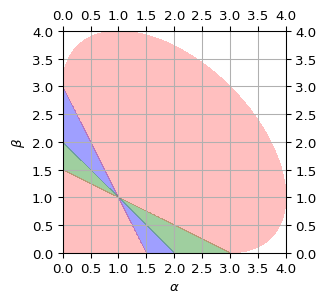
<figcaption>Figure 3: The monotonicity region</figcaption>
</figure>

Finally, simplifying yields the final monotonicity condition
(<a href="#lem-monotone-cond" class="quarto-xref">Lemma 1</a>).

Fritsch, F. N., and J. Butland. 1984. “A Method for Constructing Local
Monotone Piecewise Cubic Interpolants.” *SIAM Journal on Scientific and
Statistical Computing* 5 (2): 300–304.
<https://doi.org/10.1137/0905021>.

Fritsch, F. N., and R. E. Carlson. 1980. “Monotone Piecewise Cubic
Interpolation.” *SIAM Journal on Numerical Analysis* 17 (2): 238–46.
<https://doi.org/10.1137/0717021>.

Moler, Cleve B. 2004. *Numerical Computing with Matlab*. Society for
Industrial; Applied Mathematics.
<https://doi.org/10.1137/1.9780898717952.ch3>.